# 1. Business Understanding

## Latar Belakang:
Popularitas resep (jumlah likes) mencerminkan preferensi pengguna. Dengan menganalisis teks judul, bahan, dan langkah, dapat memprediksi resep mana yang berpotensi populer.

## Tujuan Project:
Membangun model regresi untuk memprediksi jumlah loves resep berdasarkan fitur teks.

## Business Question:
Apakah model ML dapat memprediksi loves dengan MAE yang rendah (misal ≤ 10 loves) dan R² yang baik?

## Manfaat:
- Membantu platform kuliner menampilkan resep potensial populer
- Optimalisasi rekomendasi resep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import xgboost as xgb
import pickle
import joblib
import warnings
warnings.filterwarnings('ignore')

# 2. DATA UNDERSTANDING

In [2]:
# Load dataset
df = pd.read_csv('kaloriku_processed_recipes.csv')

print("Shape dataset:", df.shape)
print("\n5 data pertama:")
display(df.head())

print("\nInfo dataset:")
df.info()

print("\nStatistik deskriptif kolom Loves:")
display(df['Loves'].describe())

Shape dataset: (14945, 9)

5 data pertama:


,Title,Ingredients,Steps,Loves,URL,Food Type,Title_cleaned,Ingredients_cleaned,Steps_cleaned
0,Ayam Woku Manado,1 Ekor Ayam Kampung (potong 12)--2 Buah Jeruk ...,Cuci bersih ayam dan tiriskan. Lalu peras jeru...,1,/id/resep/4473027-ayam-woku-manado,Ayam,ayam woku manado,1 ekor ayam kampung potong 122 buah jeruk nipi...,cuci bersih ayam dan tiriskan lalu peras jeruk...
1,Ayam goreng tulang lunak,1 kg ayam (dipotong sesuai selera jangan kecil...,"Haluskan bumbu2nya (BaPut, ketumbar, kemiri, k...",1,/id/resep/4471956-ayam-goreng-tulang-lunak,Ayam,ayam goreng tulang lunak,1 kg ayam dipotong sesuai selera jangan kecil2...,haluskan bumbu2nya baput ketumbar kemiri kunyi...
2,Ayam cabai kawin,1/4 kg ayam--3 buah cabai hijau besar--7 buah ...,Panaskan minyak di dalam wajan. Setelah minyak...,2,/id/resep/4473057-ayam-cabai-kawin,Ayam,ayam cabai kawin,14 kg ayam3 buah cabai hijau besar7 buah cabai...,panaskan minyak di dalam wajan setelah minyak ...
3,Ayam Geprek,250 gr daging ayam (saya pakai fillet)--Secuku...,Goreng ayam seperti ayam krispi--Ulek semua ba...,10,/id/resep/4473023-ayam-geprek,Ayam,ayam geprek,250 gr daging ayam saya pakai filletsecukupnya...,goreng ayam seperti ayam krispiulek semua baha...
4,Minyak Ayam,400 gr kulit ayam & lemaknya--8 siung bawang p...,Cuci bersih kulit ayam. Sisihkan--Ambil 50 ml ...,4,/id/resep/4427438-minyak-ayam,Ayam,minyak ayam,400 gr kulit ayam lemaknya8 siung bawang putih...,cuci bersih kulit ayam sisihkanambil 50 ml min...



Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14945 entries, 0 to 14944
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Title                14945 non-null  object
 1   Ingredients          14945 non-null  object
 2   Steps                14945 non-null  object
 3   Loves                14945 non-null  int64 
 4   URL                  14945 non-null  object
 5   Food Type            14945 non-null  object
 6   Title_cleaned        14945 non-null  object
 7   Ingredients_cleaned  14945 non-null  object
 8   Steps_cleaned        14945 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.0+ MB

Statistik deskriptif kolom Loves:


,Loves
count,14945.000000
mean,11.857411
std,21.796821
min,0.000000
25%,3.000000
50%,6.000000
75%,11.000000
max,939.000000


In [3]:
# Cek missing values
print("\nMissing values per kolom:")
print(df.isnull().sum())

# Cek duplikat
print(f"\nJumlah data duplikat: {df.duplicated().sum()}")


Missing values per kolom:
Title                  0
Ingredients            0
Steps                  0
Loves                  0
URL                    0
Food Type              0
Title_cleaned          0
Ingredients_cleaned    0
Steps_cleaned          0
dtype: int64

Jumlah data duplikat: 0


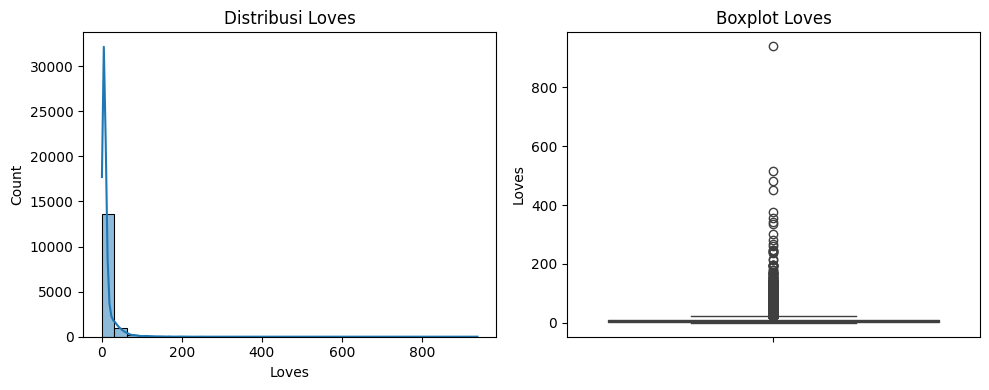

In [4]:
# Distribusi Loves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Loves'], bins=30, kde=True)
plt.title('Distribusi Loves')
plt.subplot(1,2,2)
sns.boxplot(y=df['Loves'])
plt.title('Boxplot Loves')
plt.tight_layout()
plt.show()

# 3. DATA PREPARATION & FEATURE ENGINEERING

In [5]:
# Drop baris dengan missing values pada kolom teks (jika ada)
df_clean = df.dropna(subset=['Title_cleaned', 'Ingredients_cleaned', 'Steps_cleaned']).copy()

# Fitur teks: gabungkan ketiga kolom menjadi satu dokumen
df_clean['combined_text'] = df_clean['Title_cleaned'] + ' ' + df_clean['Ingredients_cleaned'] + ' ' + df_clean['Steps_cleaned']

In [6]:
# Target
y = df_clean['Loves'].values
X = df_clean['combined_text'].values

In [7]:
# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 11956, Test size: 2989


In [8]:
# Ekstraksi fitur teks menggunakan TF-IDF (dengan batasan fitur untuk efisiensi)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))

# Transformasi data teks
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [9]:
# Normalisasi (untuk Linear Regression)
scaler = StandardScaler(with_mean=False)  # karena sparse matrix
X_train_scaled = scaler.fit_transform(X_train_tfidf)
X_test_scaled = scaler.transform(X_test_tfidf)

print(f"Dimensi fitur setelah TF-IDF: {X_train_tfidf.shape[1]}")

Dimensi fitur setelah TF-IDF: 5000


# 4. MACHINE LEARNING MODELING

In [10]:
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbosity=0)
}

results = {}

for name, model in models.items():
   # Untuk Linear Regression gunakan data yang sudah discale, untuk tree-based menggunakan sparse asli
    if name == 'Linear Regression':
        X_tr = X_train_scaled
        X_te = X_test_scaled
    else:
        X_tr = X_train_tfidf
        X_te = X_test_tfidf

    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100  # menghindari division by zero
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

# Tabel perbandingan
results_df = pd.DataFrame(results).T
print("\n=== Perbandingan Model (sebelum tuning) ===")
print(results_df)


Linear Regression
MAE: 17.89
RMSE: 24.96
R²: -0.8656
MAPE: 61724100.80%

Random Forest
MAE: 10.38
RMSE: 19.42
R²: -0.1294
MAPE: 43278098.29%

XGBoost
MAE: 10.07
RMSE: 19.94
R²: -0.1905
MAPE: 40135647.86%

=== Perbandingan Model (sebelum tuning) ===
                         MAE       RMSE        R2          MAPE
Linear Regression  17.887905  24.957808 -0.865576  6.172410e+07
Random Forest      10.375455  19.418879 -0.129402  4.327810e+07
XGBoost            10.069386  19.937087 -0.190484  4.013565e+07


# 5. HYPERPARAMETER TUNING

In [12]:
rf_params = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4]
}

rf_random = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=10,
    cv=2,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [16]:
xgb_params = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree' : [0.7, 0.9]
}
xgb_random = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42, tree_method='hist'),
    xgb_params,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
xgb_random.fit(X_train_tfidf, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 0.9],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [5, 10],
                                        'n_estimators': [50, 100],
                                        'subsample': [0.7, 0.9]},
                   scoring='r2')

# 6. EVALUASI MODEL SETELAH TUNING

In [24]:
rf_random.fit(X_train_tfidf, y_train)
rf_best = rf_random.best_estimator_
xgb_best = xgb_random.best_estimator_

models_tuned = {
    'Random Forest (tuned)': rf_best,
    'XGBoost (tuned)': xgb_best
}

results_tuned = {}

for name, model in models_tuned.items():
    y_pred = model.predict(X_test_tfidf)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-6))) * 100
    results_tuned[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}
    print(f"\n{name}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")

# Tabel perbandingan akhir
results_tuned_df = pd.DataFrame(results_tuned).T
print("\n=== Perbandingan Model Setelah Tuning ===")
print(results_tuned_df)

Fitting 2 folds for each of 10 candidates, totalling 20 fits

Random Forest (tuned)
MAE: 9.90
RMSE: 17.99
R²: 0.0306
MAPE: 41439754.49%

XGBoost (tuned)
MAE: 10.08
RMSE: 18.79
R²: -0.0577
MAPE: 39901689.32%

=== Perbandingan Model Setelah Tuning ===
                             MAE       RMSE        R2          MAPE
Random Forest (tuned)   9.903701  17.991015  0.030581  4.143975e+07
XGBoost (tuned)        10.079412  18.792218 -0.057685  3.990169e+07


In [25]:
# Analisis tercapai/tidak target (misal MAE ≤ 10 loves, karena skala loves 0-164)
best_mae = results_tuned_df['MAE'].min()
if best_mae <= 10:
    print(f"\nTarget MAE ≤ 10 tercapai dengan MAE terbaik = {best_mae:.2f}")
else:
    print(f"\nTarget MAE ≤ 10 belum tercapai (MAE terbaik = {best_mae:.2f}). Perlu improvisasi fitur atau data lebih banyak.")


Target MAE ≤ 10 tercapai dengan MAE terbaik = 9.90


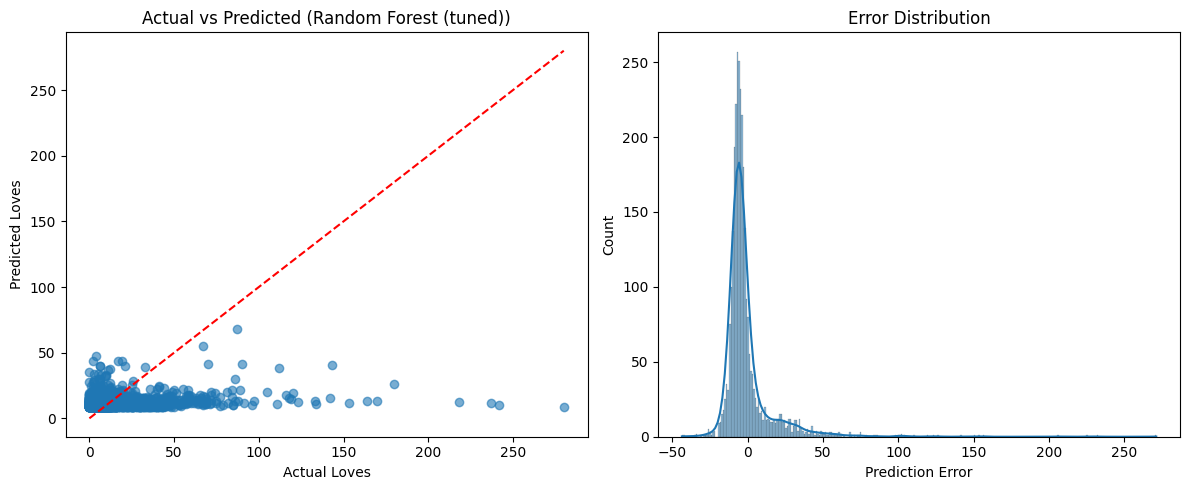

In [26]:
# Visualisasi Actual vs Prediksi untuk model terbaik (XGBoost)
best_model_name = results_tuned_df['MAE'].idxmin()
best_model = models_tuned[best_model_name]
y_pred_best = best_model.predict(X_test_tfidf)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Loves')
plt.ylabel('Predicted Loves')
plt.title(f'Actual vs Predicted ({best_model_name})')

plt.subplot(1,2,2)
errors = y_test - y_pred_best
sns.histplot(errors, kde=True)
plt.xlabel('Prediction Error')
plt.title('Error Distribution')
plt.tight_layout()
plt.show()

# 7. FEATURE IMPORTANCE ANALYSIS

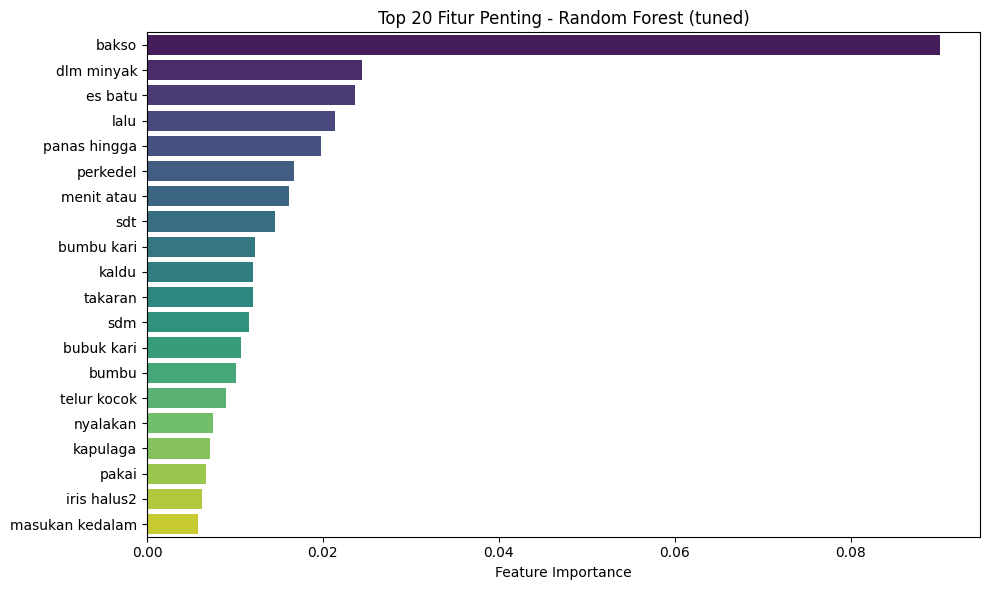

In [27]:
# Untuk model yang terbaik
if 'XGBoost' in best_model_name:
    importances = best_model.feature_importances_
else:
    importances = best_model.feature_importances_

# Ambil nama fitur dari TF-IDF vectorizer
feature_names = tfidf.get_feature_names_out()
# Urutkan berdasarkan importance
indices = np.argsort(importances)[::-1][:20]  # top 20
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]

plt.figure(figsize=(10,6))
sns.barplot(x=top_importances, y=top_features, palette='viridis')
plt.title(f'Top 20 Fitur Penting - {best_model_name}')
plt.xlabel('Feature Importance')
plt.tight_layout()
plt.show()

# 8. MODEL SAVING

In [28]:
import joblib
final_pipeline = {
    'tfidf': tfidf,
    'scaler': scaler,
    'model': best_model
}

joblib.dump(final_pipeline, 'loves_prediction_pipeline.pkl')
print("\nModel pipeline disimpan sebagai 'loves_prediction_pipeline.pkl'")



Model pipeline disimpan sebagai 'loves_prediction_pipeline.pkl'


In [29]:
# Contoh load dan prediksi
loaded_pipeline = joblib.load('loves_prediction_pipeline.pkl')
# Contoh teks baru (judul, bahan, langkah dummy)
new_text = ["ayam goreng tepung crispy bawang putih merica garam"]
new_text_tfidf = loaded_pipeline['tfidf'].transform(new_text)
# Untuk model XGBoost, tidak perlu scaling
pred_loves = loaded_pipeline['model'].predict(new_text_tfidf)
print(f"\nContoh prediksi untuk resep 'ayam goreng tepung crispy': {pred_loves[0]:.2f} loves")


Contoh prediksi untuk resep 'ayam goreng tepung crispy': 8.84 loves
